In [ ]:
#These are libraries that you should import if needed for your notebook.
#import libraries
import pandas as pd
import seaborn as sns
import numpy as np
%matplotlib inline
import matplotlib.pyplot as plots
plots.style.use('fivethirtyeight')
from google.colab import files

# Correlation Recap

Correlation Coefficient
* Measures linear association
* Based on standard units
*  -1 ≤ r ≤ 1
*  r =  1: scatter is perfect straight line sloping up
*  r = -1: scatter is perfect straight line sloping down
*  r = 0: No linear association; uncorrelated

**`Correlation`** involves two simple steps: first, **convert both variables to standard units**; second, **multiply their corresponding standard-unit values and calculate the average of the products**.

1. Converting a variable to standard units

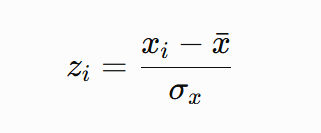

2. Multiply corresponding standardized values of X and Y, then average the products.

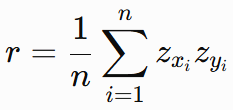

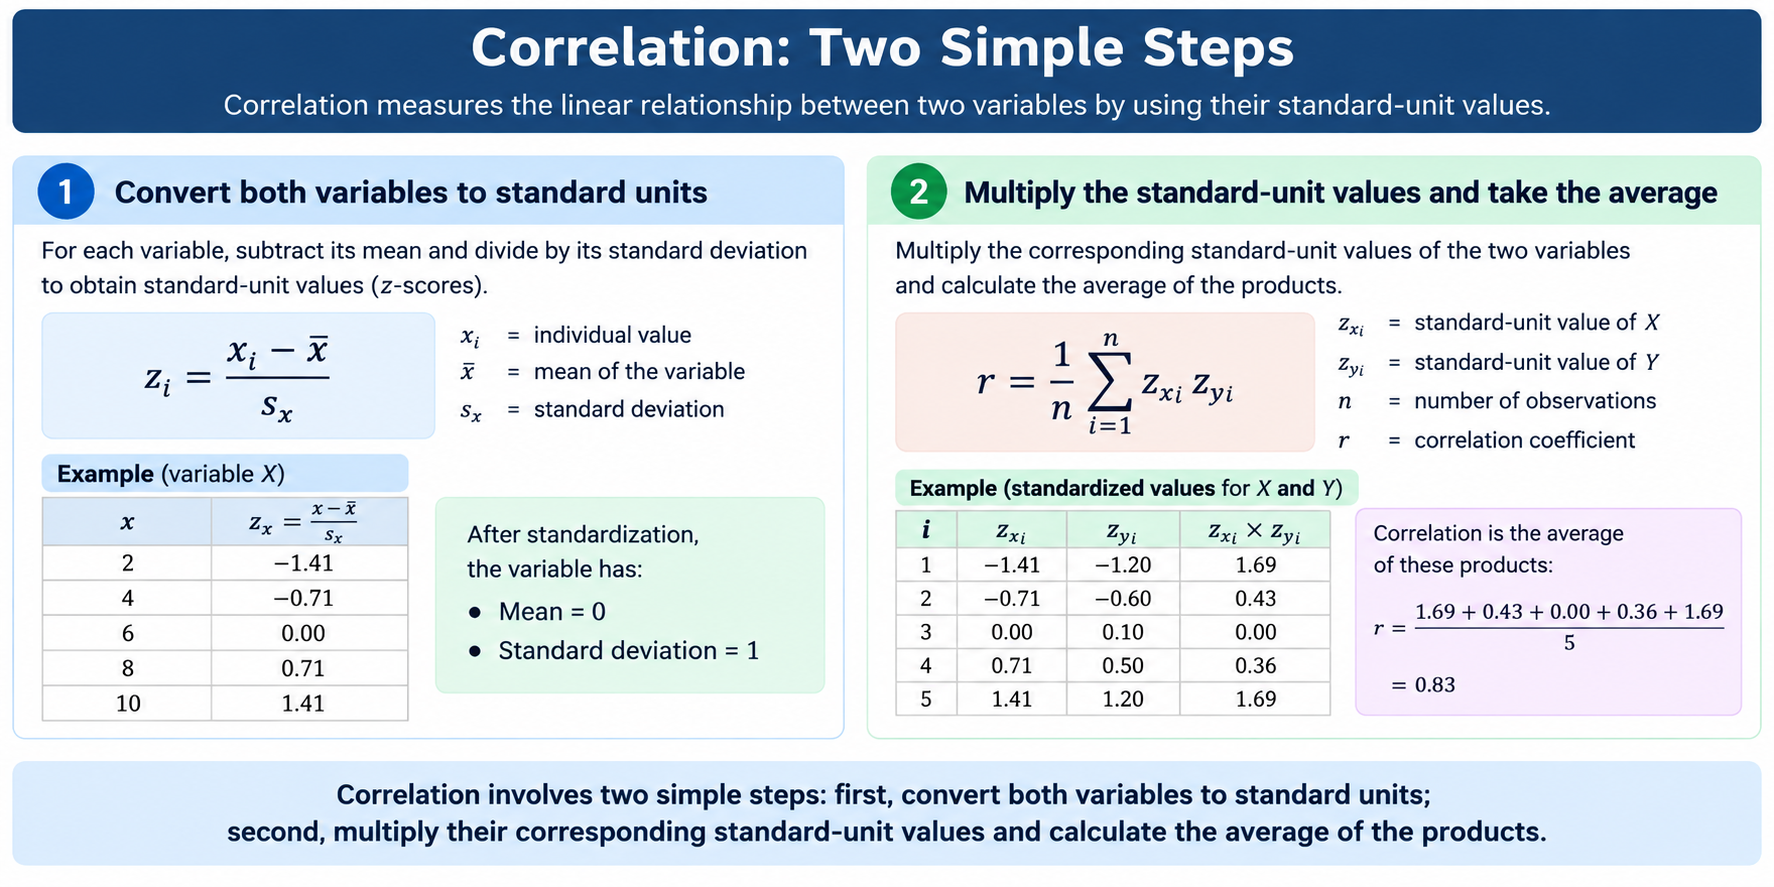

In [ ]:
def standard_units(x):
    "Convert any array of numbers to standard units."
    return (x - np.average(x)) / np.std(x)

In [ ]:
def correlation(t, x, y):
    """t is a table; x and y are column labels"""
    x_in_standard_units = standard_units(t[x])
    y_in_standard_units = standard_units(t[y])
    return np.average(x_in_standard_units * y_in_standard_units)

* The `sat2014.csv` dataset contains information about SAT performance across U.S. states in 2014. Each row represents a state and reports its SAT participation rate and average test scores.
* This dataset is useful for investigating relationships such as whether SAT participation rate is associated with average SAT performance across states.

In [ ]:
#upload the file  sat2014.csv   #
uploaded=files.upload()

Saving sat2014.csv to sat2014.csv


In [ ]:
#Read the file sat2014.csv
sat = pd.read_csv('sat2014.csv')
sat

,State,Participation Rate,Critical Reading,Math,Writing,Combined
0,North Dakota,2.3,612,620,584,1816
1,Illinois,4.6,599,616,587,1802
2,Iowa,3.1,605,611,578,1794
3,South Dakota,2.9,604,609,579,1792
4,Minnesota,5.9,598,610,578,1786
5,Michigan,3.8,593,610,581,1784
6,Wisconsin,3.9,596,608,578,1782
7,Missouri,4.2,595,597,579,1771
8,Wyoming,3.3,590,599,573,1762
9,Kansas,5.3,591,596,566,1753


# Using the Our Own defined Functions

Text(0, 0.5, 'Math')

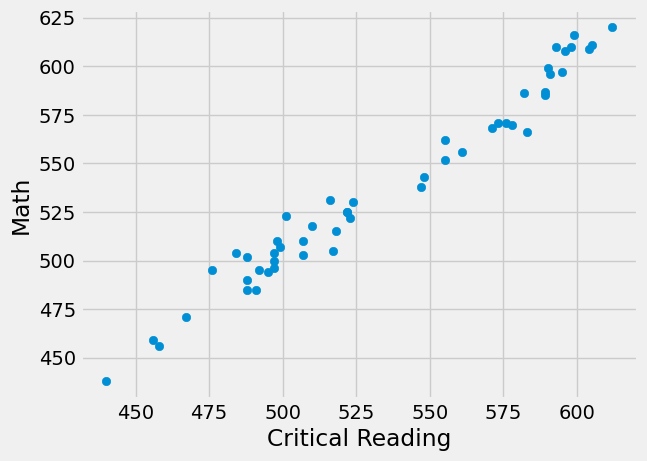

In [ ]:
# plot the scatter plot 'Critical Reading', 'Math'
plots.scatter(sat['Critical Reading'], sat['Math'])
plots.xlabel('Critical Reading')
plots.ylabel('Math')

In [ ]:
correlation(sat,'Critical Reading', 'Math')

np.float64(0.984755841106743)

In [ ]:
correlation(sat,'Critical Reading', 'Writing')

np.float64(0.989594893345872)

# Using Pandas Inbuilt Method

In [ ]:
sat.corr(numeric_only=True)

,Participation Rate,Critical Reading,Math,Writing,Combined
Participation Rate,1.000000,-0.928118,-0.889809,-0.902290,-0.911138
Critical Reading,-0.928118,1.000000,0.984756,0.989595,0.996247
Math,-0.889809,0.984756,1.000000,0.982560,0.994002
Writing,-0.902290,0.989595,0.982560,1.000000,0.995349
Combined,-0.911138,0.996247,0.994002,0.995349,1.000000


In [ ]:
#sat.corr(numeric_only=True).loc['Combined'][:-1].plot.barh()

There is a strong negative correlation between SAT participation rate and average SAT scores across states, while the individual SAT section scores are strongly positively correlated with each other.


Important: This does not mean that taking the SAT causes students to score lower. A likely explanation is selection effects: in low-participation states, the students taking the SAT may be a more academically selected group, whereas in high-participation states, a much broader range of students takes the test.

## Heatmap

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

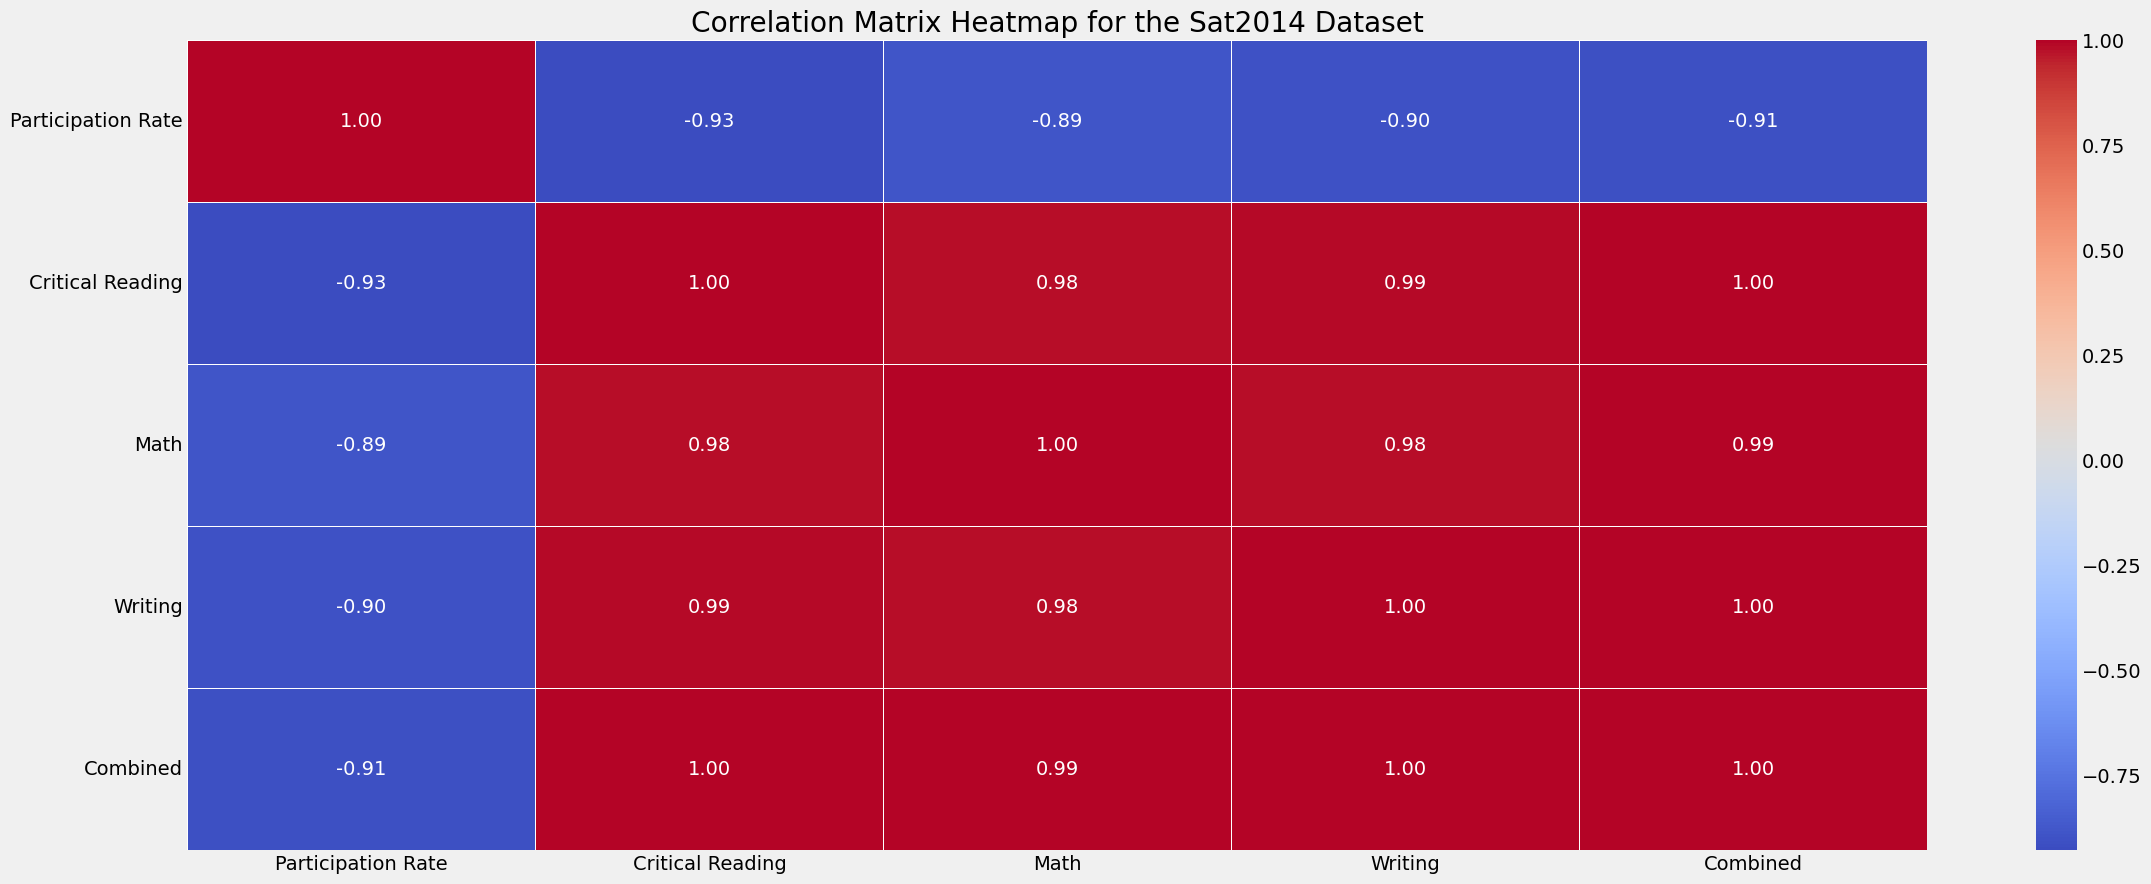

In [ ]:
corr_matrix = sat.corr(numeric_only=True)

# Plot the heatmap
plots.figure(figsize=(25, 10))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm', linewidths=0.5)
plots.title('Correlation Matrix Heatmap for the Sat2014 Dataset')
plots.savefig('corrheatmap.jpg', dpi=1500, bbox_inches='tight')

from google.colab import files
files.download( "corrheatmap.jpg" )
plots.show()

# Linear Regression

In [ ]:
#upload the file  family_height.csv   # Note: Child heights are the **adult** heights of children in a family
uploaded=files.upload()

Saving family_heights.csv to family_heights.csv


In [ ]:
#Read the file family_heights.csv
families = pd.read_csv('family_heights.csv')
families

,family,father,mother,child,children,order,sex
0,1,78.5,67.0,73.2,4,1,male
1,1,78.5,67.0,69.2,4,2,female
2,1,78.5,67.0,69.0,4,3,female
3,1,78.5,67.0,69.0,4,4,female
4,2,75.5,66.5,73.5,4,1,male
...,...,...,...,...,...,...,...
929,203,62.0,66.0,64.0,3,1,male
930,203,62.0,66.0,62.0,3,2,female
931,203,62.0,66.0,61.0,3,3,female
932,204,62.5,63.0,66.5,2,1,male


In [ ]:
families_1 = families.copy()

In [ ]:

# CReate a new table called heights with a column titled 'Parent Average' with values of the array parent_avgs and also another column "Child" with values from the families table's column 'child'

parent_avgs = (families['father'] + families['mother'])/2
heights = pd.DataFrame()
heights['Parent Average'] = parent_avgs
heights['Child'] = families['child']
heights

,Parent Average,Child
0,72.75,73.2
1,72.75,69.2
2,72.75,69.0
3,72.75,69.0
4,71.00,73.5
...,...,...
929,64.00,64.0
930,64.00,62.0
931,64.00,61.0
932,62.75,66.5


In [ ]:
def predict_child(h):
    """Predict the height of a child whose parents have a parent average height of p_avg.

    The prediction is the average height of the children whose parent average height is
    in the range p_avg plus or minus 0.5.
    """
    # Filter rows where 'Parent Average' is within the specified range
    nearby = heights[(heights['Parent Average'] >= h - 0.5) & (heights['Parent Average'] <= h + 0.5)]

    # Calculate the average height of the 'Child' column
    return np.average(nearby['Child'])

In [ ]:
# Assuming `heights` is a DataFrame and 'Parent Average' is an existing column
heights['Prediction'] = heights['Parent Average'].apply(predict_child)

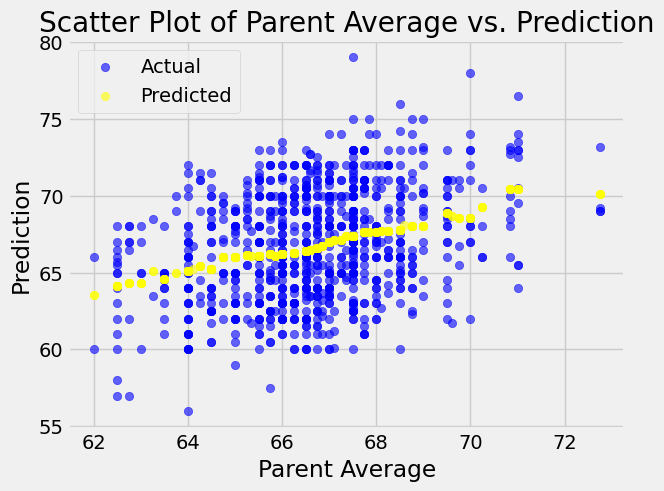

In [ ]:
# Scatter plot of 'Parent Average' vs 'Prediction'

plots.scatter(heights['Parent Average'], heights['Child'], color='blue', alpha=0.6)

# Line plot of 'Parent Average' vs 'Prediction'
plots.scatter(heights['Parent Average'], heights['Prediction'], color='yellow', alpha=0.6)

# Adding labels and title
plots.xlabel('Parent Average')
plots.ylabel('Prediction')
plots.title('Scatter Plot of Parent Average vs. Prediction')
plots.legend(['Actual', 'Predicted'])
# Display the plot
plots.show()

In [ ]:
def nn_prediction_height(p_avg):
    """Predict the height of a child whose parents have a parent average height of p_avg.

    The prediction is the average height of the children whose parent average height is
    in the range p_avg plus or minus 0.5.
    """

    nearby = heights[(heights['Parent Average'] >= p_avg - 0.5) & (heights['Parent Average'] <= p_avg + 0.5)]

    # Calculate the average height of the 'Child' column
    return np.average(nearby['Child'])

In [ ]:
def standard_units(x):
    "Convert any array of numbers to standard units."
    return (x - np.average(x)) / np.std(x)


def correlation(t, x, y):
    """t is a table; x and y are column labels"""
    x_in_standard_units = standard_units(t[x])
    y_in_standard_units = standard_units(t[y])
    return np.average(x_in_standard_units * y_in_standard_units)


def slope(t, x, y):
    """ Computes the slope of the regression line, like correlation above """
    r = correlation(t, x, y)
    y_sd = np.std(t[y])
    x_sd = np.std(t[x])
    return r * y_sd / x_sd


def intercept(t, x, y):
    """ Computes the intercept of the regression line, like slope above """
    x_mean = np.mean(t[x])
    y_mean = np.mean(t[y])
    return y_mean - slope(t, x, y)*x_mean





In [ ]:
# Assuming `heights` is a DataFrame and 'Parent Average' is an existing column
heights['Nearest neighbor prediction'] = heights['Parent Average'].apply(nn_prediction_height)

In [ ]:
heights

,Parent Average,Child,Prediction,Nearest neighbor prediction
0,72.75,73.2,70.100000,70.100000
1,72.75,69.2,70.100000,70.100000
2,72.75,69.0,70.100000,70.100000
3,72.75,69.0,70.100000,70.100000
4,71.00,73.5,70.415789,70.415789
...,...,...,...,...
929,64.00,64.0,65.080682,65.080682
930,64.00,62.0,65.080682,65.080682
931,64.00,61.0,65.080682,65.080682
932,62.75,66.5,64.351724,64.351724


In [ ]:
# Create a new table based on heights
heights_with_predictions = heights.copy()
heights_with_predictions

,Parent Average,Child,Prediction,Nearest neighbor prediction
0,72.75,73.2,70.100000,70.100000
1,72.75,69.2,70.100000,70.100000
2,72.75,69.0,70.100000,70.100000
3,72.75,69.0,70.100000,70.100000
4,71.00,73.5,70.415789,70.415789
...,...,...,...,...
929,64.00,64.0,65.080682,65.080682
930,64.00,62.0,65.080682,65.080682
931,64.00,61.0,65.080682,65.080682
932,62.75,66.5,64.351724,64.351724


In [ ]:
predicted_heights_slope = slope(heights, 'Parent Average', 'Child')
predicted_heights_intercept = intercept(heights, 'Parent Average', 'Child')
[predicted_heights_slope, predicted_heights_intercept]


[np.float64(0.6644952623525905), np.float64(22.461839955758656)]

In [ ]:
heights_with_predictions['Regression Prediction'] = (
    predicted_heights_slope * heights_with_predictions['Parent Average'] + predicted_heights_intercept
)

# Display the updated DataFrame
heights_with_predictions

,Parent Average,Child,Prediction,Nearest neighbor prediction,Regression Prediction
0,72.75,73.2,70.100000,70.100000,70.803870
1,72.75,69.2,70.100000,70.100000,70.803870
2,72.75,69.0,70.100000,70.100000,70.803870
3,72.75,69.0,70.100000,70.100000,70.803870
4,71.00,73.5,70.415789,70.415789,69.641004
...,...,...,...,...,...
929,64.00,64.0,65.080682,65.080682,64.989537
930,64.00,62.0,65.080682,65.080682,64.989537
931,64.00,61.0,65.080682,65.080682,64.989537
932,62.75,66.5,64.351724,64.351724,64.158918


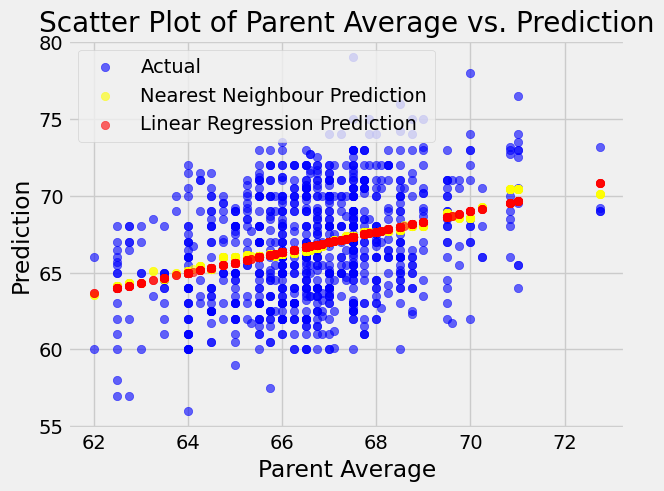

In [ ]:
# Scatter plot of 'Parent Average' vs 'Prediction'

plots.scatter(heights_with_predictions['Parent Average'], heights_with_predictions['Child'], color='blue', alpha=0.6)

# Line plot of 'Parent Average' vs 'Nearest neighbour prediction'
plots.scatter(heights_with_predictions['Parent Average'], heights_with_predictions['Nearest neighbor prediction'], color='yellow', alpha=0.6)


# Line plot of 'Parent Average' vs 'Regression Prediction'
plots.scatter(heights_with_predictions['Parent Average'], heights_with_predictions['Regression Prediction'], color='red', alpha=0.6)



# Adding labels and title
plots.xlabel('Parent Average')
plots.ylabel('Prediction')
plots.title('Scatter Plot of Parent Average vs. Prediction')
plots.legend(['Actual', 'Nearest Neighbour Prediction', 'Linear Regression Prediction'])
# Display the plot
plots.show()

## Statsmodels

In [ ]:
# Using the statsmodels library
import statsmodels.api as sm

In [ ]:
x= np.array(heights['Parent Average'])
y= heights['Child'].values

x1 = sm.add_constant(x)
lin_model = sm.OLS(y, x1)
regr_results = lin_model.fit()
print(regr_results)

In [ ]:
print(regr_results.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.104
Model:                            OLS   Adj. R-squared:                  0.103
Method:                 Least Squares   F-statistic:                     108.1
Date:                Thu, 10 Sep 2026   Prob (F-statistic):           4.87e-24
Time:                        20:42:36   Log-Likelihood:                -2464.5
No. Observations:                 934   AIC:                             4933.
Df Residuals:                     932   BIC:                             4943.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         22.4618      4.260      5.273      0.0

## Sklearn

In [ ]:
#Linear Regression using Sklearn

from sklearn import linear_model
from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_absolute_percentage_error

from sklearn.linear_model import LinearRegression
linmodel = linear_model.LinearRegression(fit_intercept=True)
linmodel.fit(x.reshape(-1, 1), y)
LinearRegression()

LinearRegression()

In [ ]:
(slope_1, intercept) = (linmodel.coef_, linmodel.intercept_)
print(slope_1, intercept)

[0.66449526] 22.461839955758784


# Two Independent Variables (Predictors)

In [ ]:
# Convert sex to numbers
# male = 1, female = 0
#families_1 = families.copy()


In [ ]:
families_1['Parent Average'] = (families_1['father'] + families_1['mother']) / 2

In [ ]:
families_1

,family,father,mother,child,children,order,sex,Parent Average
0,1,78.5,67.0,73.2,4,1,male,72.75
1,1,78.5,67.0,69.2,4,2,female,72.75
2,1,78.5,67.0,69.0,4,3,female,72.75
3,1,78.5,67.0,69.0,4,4,female,72.75
4,2,75.5,66.5,73.5,4,1,male,71.00
...,...,...,...,...,...,...,...,...
929,203,62.0,66.0,64.0,3,1,male,64.00
930,203,62.0,66.0,62.0,3,2,female,64.00
931,203,62.0,66.0,61.0,3,3,female,64.00
932,204,62.5,63.0,66.5,2,1,male,62.75


In [ ]:
families_1['sex_numeric'] = families_1['sex'].map({'male': 1, 'female': 0})
families_1

,family,father,mother,child,children,order,sex,Parent Average,sex_numeric
0,1,78.5,67.0,73.2,4,1,male,72.75,1
1,1,78.5,67.0,69.2,4,2,female,72.75,0
2,1,78.5,67.0,69.0,4,3,female,72.75,0
3,1,78.5,67.0,69.0,4,4,female,72.75,0
4,2,75.5,66.5,73.5,4,1,male,71.00,1
...,...,...,...,...,...,...,...,...,...
929,203,62.0,66.0,64.0,3,1,male,64.00,1
930,203,62.0,66.0,62.0,3,2,female,64.00,0
931,203,62.0,66.0,61.0,3,3,female,64.00,0
932,204,62.5,63.0,66.5,2,1,male,62.75,1


## Sklearn

In [ ]:
#  Select input variables and target
X = families_1[['Parent Average', 'sex_numeric']]
y = families_1['child']

In [ ]:
# Create and train the model
# from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X, y)

LinearRegression()

In [ ]:
#  Make predictions
families_1['predicted_child_height'] = model.predict(X)

In [ ]:
families_1

,family,father,mother,child,children,order,sex,Parent Average,sex_numeric,predicted_child_height
0,1,78.5,67.0,73.2,4,1,male,72.75,1,73.647755
1,1,78.5,67.0,69.2,4,2,female,72.75,0,68.432376
2,1,78.5,67.0,69.0,4,3,female,72.75,0,68.432376
3,1,78.5,67.0,69.0,4,4,female,72.75,0,68.432376
4,2,75.5,66.5,73.5,4,1,male,71.00,1,72.394801
...,...,...,...,...,...,...,...,...,...,...
929,203,62.0,66.0,64.0,3,1,male,64.00,1,67.382983
930,203,62.0,66.0,62.0,3,2,female,64.00,0,62.167604
931,203,62.0,66.0,61.0,3,3,female,64.00,0,62.167604
932,204,62.5,63.0,66.5,2,1,male,62.75,1,66.488015


## Statsmodels

In [ ]:
#  Select input variables and target
X = families_1[['Parent Average', 'sex_numeric']]
y = families_1['child']

In [ ]:
# Add a constant for the intercept
X = sm.add_constant(X)

# Create and train the regression model
model = sm.OLS(y, X).fit()

# View regression results
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                  child   R-squared:                       0.634
Model:                            OLS   Adj. R-squared:                  0.633
Method:                 Least Squares   F-statistic:                     807.2
Date:                Thu, 10 Sep 2026   Prob (F-statistic):          4.70e-204
Time:                        20:51:26   Log-Likelihood:                -2046.1
No. Observations:                 934   AIC:                             4098.
Df Residuals:                     931   BIC:                             4113.
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
const             16.3453      2.728      5.

In [ ]:
# Make predictions
families_1['predicted_child_height_Stats'] = model.predict(X)

In [ ]:
families_1

,family,father,mother,child,children,order,sex,Parent Average,sex_numeric,predicted_child_height,predicted_child_height_Stats
0,1,78.5,67.0,73.2,4,1,male,72.75,1,73.647755,73.647755
1,1,78.5,67.0,69.2,4,2,female,72.75,0,68.432376,68.432376
2,1,78.5,67.0,69.0,4,3,female,72.75,0,68.432376,68.432376
3,1,78.5,67.0,69.0,4,4,female,72.75,0,68.432376,68.432376
4,2,75.5,66.5,73.5,4,1,male,71.00,1,72.394801,72.394801
...,...,...,...,...,...,...,...,...,...,...,...
929,203,62.0,66.0,64.0,3,1,male,64.00,1,67.382983,67.382983
930,203,62.0,66.0,62.0,3,2,female,64.00,0,62.167604,62.167604
931,203,62.0,66.0,61.0,3,3,female,64.00,0,62.167604,62.167604
932,204,62.5,63.0,66.5,2,1,male,62.75,1,66.488015,66.488015
